# LNA gain measurement with ADALM-PLUTO

まずPlutoへ接続し、現在の設定を読み出して疎通を確認します。  
このプロジェクトでは2チャネルを扱うため、`adi.Pluto`ではなく`adi.ad9361`を使用します。


## 0. Pythonパッケージの準備

下のセルは、選択中のNotebookカーネルに必要なパッケージがない場合だけ実行してください。  
実行後にカーネルの再起動を求められた場合は、再起動してから次へ進みます。


In [645]:
# 必要な場合だけ、先頭の # を外して実行する
#%pip install pyadi-iio numpy matplotlib


## 1. Plutoへ接続

USB経由のネットワークURI `ip:192.168.2.1` を使用します。  
このセルではRF設定を変更せず、現在値の読み出しだけを行います。


In [646]:
import os
from pathlib import Path
from importlib.util import find_spec

# Windowsではpylibiioが使用するDLLの場所を、adiのimport前に指定する
if os.name == "nt":
    dll_relative_path = Path("tmp/libiio-v0.26/Windows-VS-2022-x64")
    search_roots = [Path.cwd(), *Path.cwd().parents]
    libiio_dir = next(
        (root / dll_relative_path for root in search_roots if (root / dll_relative_path).is_dir()),
        None,
    )
    if libiio_dir is None:
        raise FileNotFoundError(
            "libiio.dllのフォルダが見つかりません。Notebookをこのプロジェクト内で実行してください。"
        )
    libiio_dir = libiio_dir.resolve()
    os.environ["PATH"] = str(libiio_dir) + os.pathsep + os.environ.get("PATH", "")
    # Python 3.8以降のWindows DLL検索にも登録し、ハンドルを保持する
    if "libiio_dll_handle" not in globals():
        libiio_dll_handle = os.add_dll_directory(str(libiio_dir))

if find_spec("adi") is None:
    raise ModuleNotFoundError(
        "pyadi-iioがありません。直前のインストールセルを実行し、"
        "カーネルを再起動してください。"
    )

import adi

PLUTO_URI = "ip:192.168.2.1"

# このセルを再実行した場合は、古い接続を先に閉じる
if "sdr" in globals() and sdr is not None:
    try:
        sdr.close()
    except Exception:
        pass

try:
    sdr = adi.ad9361(uri=PLUTO_URI)
except Exception as exc:
    sdr = None
    raise ConnectionError(
        f"Plutoへ接続できませんでした ({PLUTO_URI})。"
        "USB接続、Plutoの起動、192.168.2.1への到達性を確認してください。"
    ) from exc

# 属性を実機から読み返せれば接続成功
pluto_status = {
    "URI": PLUTO_URI,
    "RX LO [Hz]": int(sdr.rx_lo),
    "TX LO [Hz]": int(sdr.tx_lo),
    "Sample rate [S/s]": int(sdr.sample_rate),
    "RX RF bandwidth [Hz]": int(sdr.rx_rf_bandwidth),
}

print("Pluto connection: OK")
for name, value in pluto_status.items():
    print(f"  {name}: {value}")


Pluto connection: OK
  URI: ip:192.168.2.1
  RX LO [Hz]: 2400000000
  TX LO [Hz]: 2400000000
  Sample rate [S/s]: 30720000
  RX RF bandwidth [Hz]: 20000000


# 送受信テスト
2.4GHzのWI-FI信号を想定して送受信の設定をする．
2.4GHz丁度の信号を受信できるように若干LO周波数をずらして送信する．
ADCは最大サンプルレートは61.44 MSPS
RF帯域幅は20MHzが最大である．

Wifiの使用周波数は2.4GHzから2.5GHzの範囲である．


AD9361の2r2tモードでは最大サンプルレートは30.72 MSPSであるらしい．
RFフロントエンドの帯域幅20MHzとは±10MHzの範囲であるらしい．
なのでRFフロントエンドの帯域は30MHzでもいい．

In [647]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Tx1 / Rx1 基本設定
# ============================================

# 使用チャネル
# channel 0 = Tx1 / Rx1
sdr.rx_enabled_channels = [0]
sdr.tx_enabled_channels = [0]

# サンプルレート
FS = int(30.72e6)          # 30.72 MSPS(2e2tモードでは最大30.72 MSPS)
# RF中心周波数
FC = int(2.4e9)        # 2.4 GHz
# RFフロントエンド帯域
RF_BW = int(20e6)      # 20 MHz

#QPSK設定
SPS = 16            # Samples per symbol
RS = FS / SPS       # Symbol rate

#QSPKをDCからずらして送信
F_SHIFT = int(6e6)    # 6 MHz

#1周期のシンボル数
N_SYM = 4096

# ============================================
# Pluto設定
# ============================================

sdr.sample_rate = FS

sdr.rx_lo = FC
sdr.tx_lo = FC

sdr.rx_rf_bandwidth = RF_BW
sdr.tx_rf_bandwidth = RF_BW

# RX Gainの設定
sdr.gain_control_mode = "manual"
sdr.rx_hardwaregain_chan0 = 0

sdr.tx_hardwaregain_chan0 = -70

print(f"Sample rate : {FS/1e6:.3f} MSPS")
print(f"Symbol rate : {RS/1e6:.3f} Msymbol/s")
print(f"LO          : {FC/1e9:.6f} GHz")
print(f"QPSK center : {(FC + F_SHIFT)/1e9:.6f} GHz")

Sample rate : 30.720 MSPS
Symbol rate : 1.920 Msymbol/s
LO          : 2.400000 GHz
QPSK center : 2.406000 GHz


In [648]:
# ============================================
# QPSK symbols
# ============================================

rng = np.random.default_rng(12345)

# 1シンボルにつき2bit
bits = rng.integers(
    0,
    2,
    size=(N_SYM, 2)
)

# QPSK mapping
#
# bit -> I,Q
# 0 -> +1
# 1 -> -1
#
I_sym = 1 - 2 * bits[:, 0]
Q_sym = 1 - 2 * bits[:, 1]

symbols = (
    I_sym + 1j * Q_sym
) / np.sqrt(2)

print("First 10 bits:")
print(bits[:10])

print()
print("First 10 QPSK symbols:")
print(symbols[:10])

First 10 bits:
[[1 0]
 [1 0]
 [0 1]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]]

First 10 QPSK symbols:
[-0.70710678+0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
 -0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
 -0.70710678-0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j
 -0.70710678-0.70710678j]


# 送信前のコンスタレーションを見る

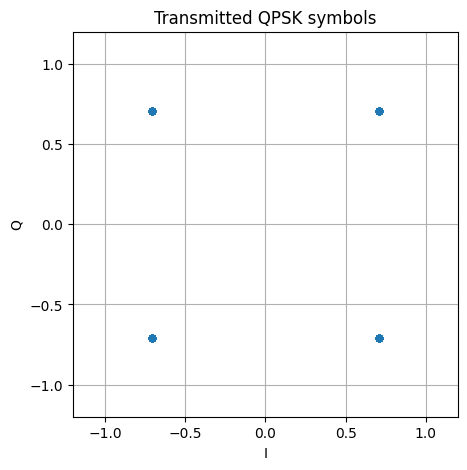

In [649]:
plt.figure(figsize=(5, 5))

plt.scatter(
    np.real(symbols),
    np.imag(symbols),
    s=20
)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("Transmitted QPSK symbols")

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

plt.grid()
plt.gca().set_aspect("equal")

plt.show()

In [650]:
# ============================================
# Upsampling by simple repetition
# ============================================

tx_baseband = np.repeat(
    symbols,
    SPS
)

print(f"Symbols      : {len(symbols)}")
print(f"TX samples   : {len(tx_baseband)}")
print(f"Samples/sym  : {SPS}")

Symbols      : 4096
TX samples   : 65536
Samples/sym  : 16


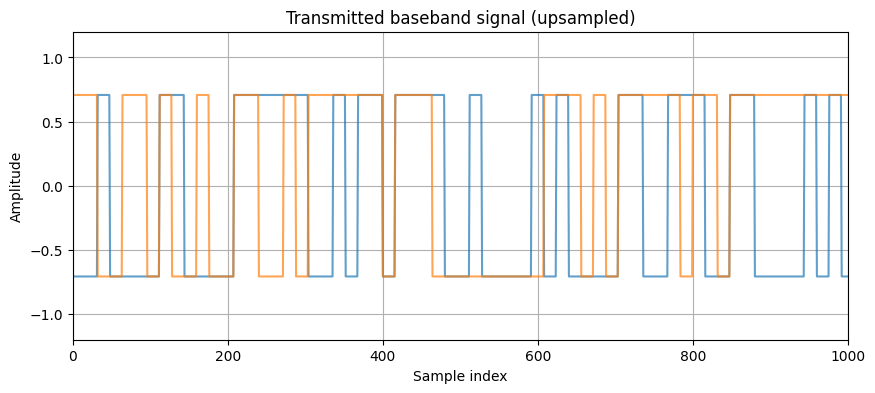

In [651]:
plt.figure(figsize=(10, 4))
plt.plot(
    np.real(tx_baseband),
    label="I",
    alpha=0.7
)
plt.plot(
    np.imag(tx_baseband),
    label="Q",
    alpha=0.7
)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.title("Transmitted baseband signal (upsampled)")
plt.grid()
plt.show()



In [652]:
# ============================================
# Frequency shift to +3 MHz
# ============================================

n = np.arange(len(tx_baseband))

digital_lo = np.exp(
    1j * 2 * np.pi * F_SHIFT / FS * n
)

# デジタル的にも単に信号同士を掛け算すればよいんだっけ
tx_shifted = tx_baseband * digital_lo

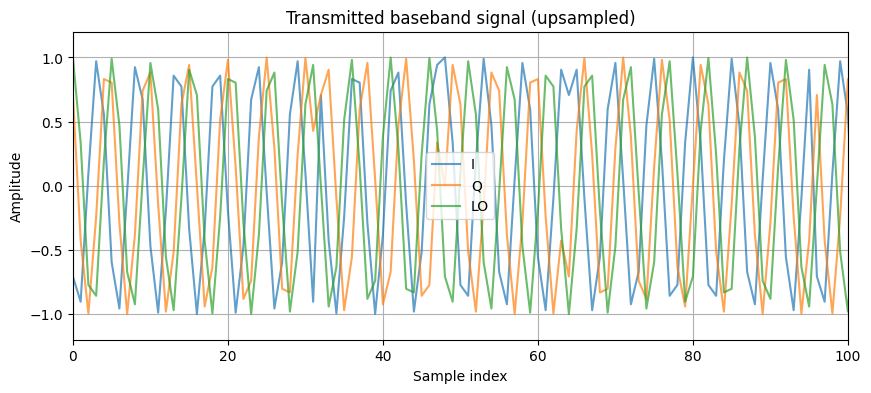

In [653]:
plt.figure(figsize=(10, 4))
plt.plot(
    np.real(tx_shifted),
    label="I",
    alpha=0.7
)
plt.plot(
    np.imag(tx_shifted),
    label="Q",
    alpha=0.7
)
plt.plot(
    np.real(digital_lo),
    label="LO",
    alpha=0.7
)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.xlim(0, 100)
plt.ylim(-1.2, 1.2)
plt.title("Transmitted baseband signal (upsampled)")
plt.legend()
plt.grid()
plt.show()

In [654]:
# ============================================
# TX amplitude
# ============================================

TX_SCALE = 0.20 * (2**14)

tx_iq = (
    TX_SCALE * tx_shifted
).astype(np.complex64)

print(f"Maximum magnitude = {np.max(np.abs(tx_iq)):.1f}")

Maximum magnitude = 3276.8


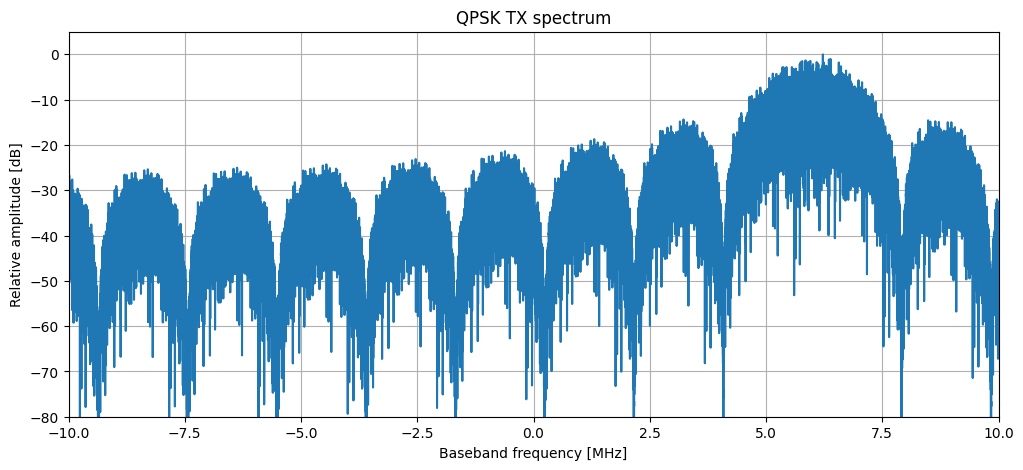

In [655]:
N = len(tx_iq)

window = np.hanning(N)

TX_FFT = np.fft.fftshift(
    np.fft.fft(
        tx_iq * window
    )
)

freq = np.fft.fftshift(
    np.fft.fftfreq(
        N,
        d=1/FS
    )
)

TX_dB = 20 * np.log10(
    np.abs(TX_FFT) + 1e-12
)

TX_dB -= np.max(TX_dB)

plt.figure(figsize=(12, 5))

plt.plot(
    freq / 1e6,
    TX_dB
)

plt.xlabel("Baseband frequency [MHz]")
plt.ylabel("Relative amplitude [dB]")
plt.title("QPSK TX spectrum")

plt.xlim(-10, 10)
plt.ylim(-80, 5)

plt.grid()

plt.show()

In [656]:
# ============================================
# Start cyclic TX
# ============================================

# 前回のTX bufferが残っていたら削除
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

sdr.tx_cyclic_buffer = True

sdr.tx(tx_iq)

print("QPSK TX started")
print(f"RF center = {(FC + F_SHIFT)/1e9:.6f} GHz")

QPSK TX started
RF center = 2.406000 GHz


In [657]:
# ============================================
# RX
# ============================================

sdr.rx_buffer_size = len(tx_iq)

# 数回読み捨てる
for _ in range(3):
    rx = sdr.rx()

print(f"Received samples : {len(rx)}")
print(f"dtype            : {rx.dtype}")

print()
print("First 5 samples:")
print(rx[:5])

Received samples : 65536
dtype            : complex128

First 5 samples:
[-182.+458.j -151.+259.j   58.+269.j  131.+431.j   82.+592.j]


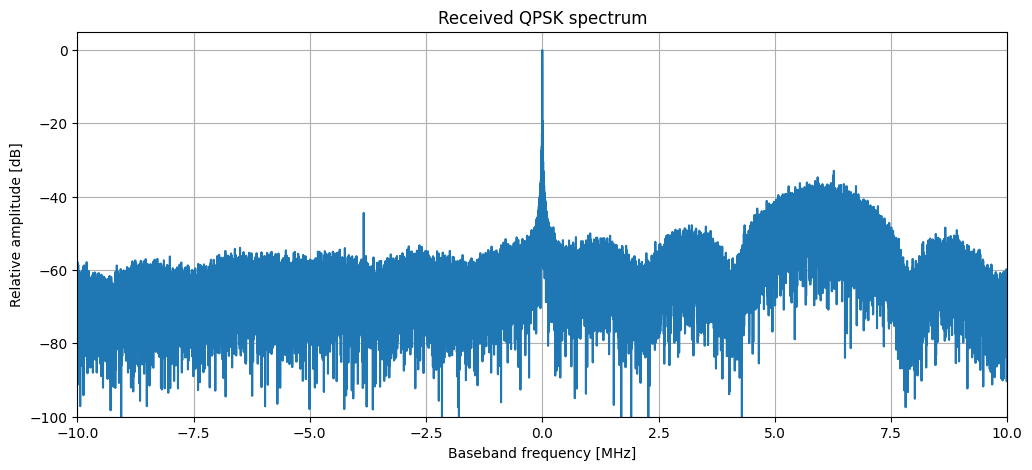

In [658]:
# ============================================
# RX spectrum
# ============================================

N_RX = len(rx)

rx_no_dc = rx - np.mean(rx)

window = np.hanning(N_RX)

RX_FFT = np.fft.fftshift(
    np.fft.fft(
        rx_no_dc * window
    )
)

freq_rx = np.fft.fftshift(
    np.fft.fftfreq(
        N_RX,
        d=1/FS
    )
)

RX_dB = 20 * np.log10(
    np.abs(RX_FFT) + 1e-12
)

RX_dB -= np.max(RX_dB)

plt.figure(figsize=(12, 5))

plt.plot(
    freq_rx / 1e6,
    RX_dB
)

plt.xlabel("Baseband frequency [MHz]")
plt.ylabel("Relative amplitude [dB]")
plt.title("Received QPSK spectrum")

plt.xlim(-10, 10)
plt.ylim(-100, 5)

plt.grid()

plt.show()

In [659]:
# ============================================
# Digital downconversion
# ============================================

n_rx = np.arange(len(rx))

rx_bb = rx * np.exp(
    -1j * 2 * np.pi * F_SHIFT / FS * n_rx
)

# DC offset除去
rx_bb -= np.mean(rx_bb)

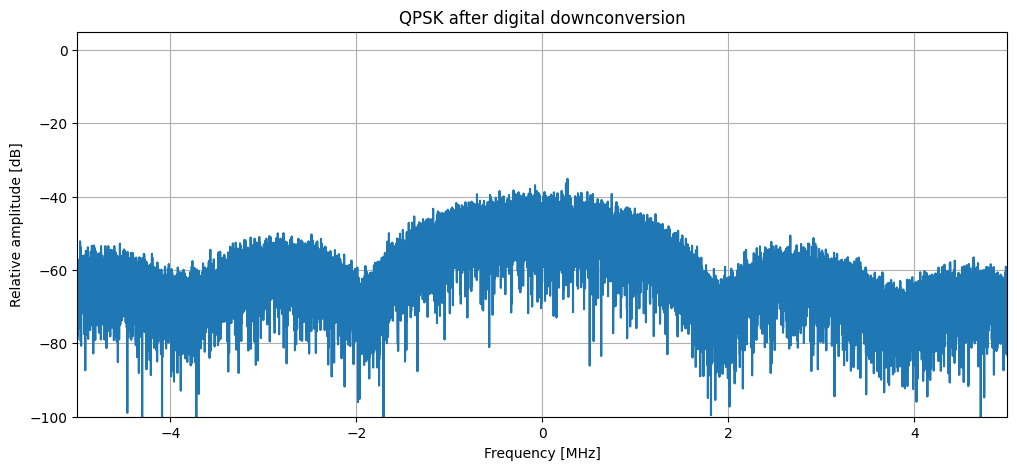

In [660]:
BB_FFT = np.fft.fftshift(
    np.fft.fft(
        rx_bb * np.hanning(len(rx_bb))
    )
)

BB_dB = 20 * np.log10(
    np.abs(BB_FFT) + 1e-12
)

BB_dB -= np.max(BB_dB)

plt.figure(figsize=(12, 5))

plt.plot(
    freq_rx / 1e6,
    BB_dB
)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Relative amplitude [dB]")
plt.title("QPSK after digital downconversion")

plt.xlim(-5, 5)
plt.ylim(-100, 5)

plt.grid()

plt.show()

In [661]:
# ============================================
# Simple matched filter
# ============================================

h = np.ones(SPS) / SPS

rx_mf = np.convolve(
    rx_bb,
    h,
    mode="same"
)

In [662]:
# ============================================
# Symbol timing search
# ============================================

scores = []

for phase in range(SPS):

    z = rx_mf[phase::SPS]

    # 端の過渡部分を除外
    if len(z) > 40:
        z = z[20:-20]

    # 振幅の影響を取り除く
    z_norm = z / (
        np.abs(z) + 1e-12
    )

    # QPSKは4乗すると位相が揃う
    score = np.abs(
        np.mean(z_norm**4)
    )

    scores.append(score)

best_phase = int(
    np.argmax(scores)
)

print(f"Best sampling phase = {best_phase}")
print(f"Timing score        = {scores[best_phase]:.4f}")

Best sampling phase = 9
Timing score        = 0.8190


In [663]:
# ============================================
# Extract symbols
# ============================================

rx_symbols = rx_mf[
    best_phase::SPS
]

# 最初と最後は捨てる
rx_symbols = rx_symbols[20:-20]

# RMSで正規化
rx_symbols = rx_symbols / np.sqrt(
    np.mean(
        np.abs(rx_symbols)**2
    )
)

print(f"Received symbols = {len(rx_symbols)}")

Received symbols = 4056


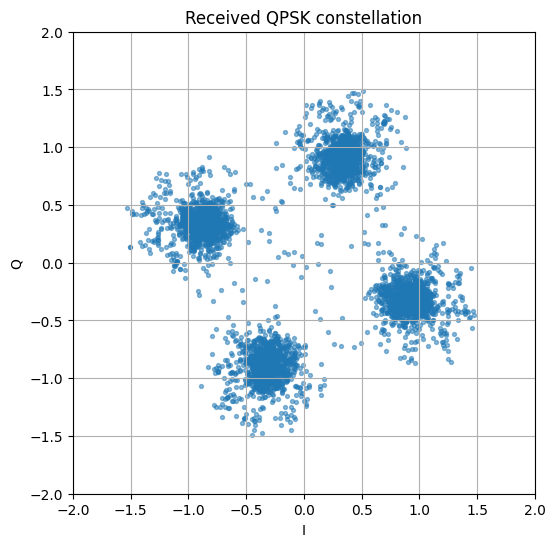

In [664]:
plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_symbols),
    np.imag(rx_symbols),
    s=8,
    alpha=0.5
)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("Received QPSK constellation")

plt.grid()
plt.gca().set_aspect("equal")

plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.show()

17. 位相回転を自動補正する
QPSKの場合、4乗するとデータによる90°単位の位相が消えるので、キャリア位相をある程度推定できます。

In [665]:
# ============================================
# QPSK carrier phase correction
# ============================================

phase_est = (
    np.angle(
        -np.mean(rx_symbols**4)
    ) / 4
)

rx_symbols_corrected = (
    rx_symbols
    * np.exp(-1j * phase_est)
)

print(
    f"Estimated phase offset = "
    f"{np.degrees(phase_est):.2f} deg"
)

Estimated phase offset = 25.10 deg


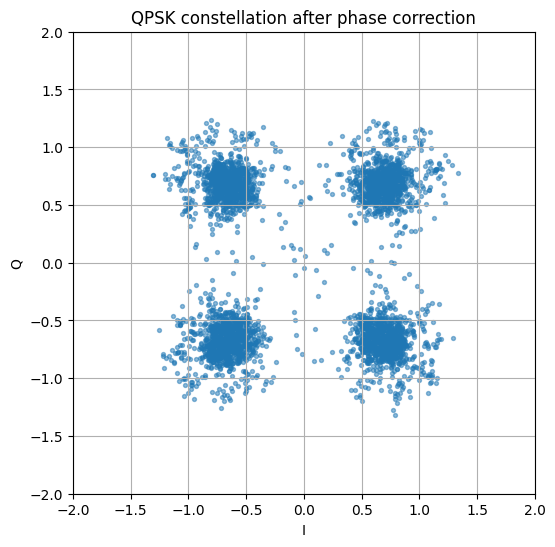

In [666]:
plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_symbols_corrected),
    np.imag(rx_symbols_corrected),
    s=8,
    alpha=0.5
)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("QPSK constellation after phase correction")

plt.grid()
plt.gca().set_aspect("equal")

plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.show()

# TXストップ

In [667]:
try:
    sdr.tx_destroy_buffer()
    print("TX stopped")
except Exception as exc:
    print(exc)

TX stopped


## 接続を閉じる場合

測定セルを追加している間は接続を維持して構いません。終了時や再接続前には次を実行できます。


In [668]:
#必要なときだけ実行する
if sdr is not None:
    sdr.close()
    sdr = None
    print("Pluto connection: closed")

Pluto connection: closed
